In [1]:
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from typing import TypedDict, Annotated
import operator
import os


In [2]:
load_dotenv()

True

In [3]:
model=ChatGroq(model=os.environ["GROQ_MODEL"])

In [4]:
class EvalutationSchema(BaseModel):
    feedback: str = Field(description="detailed feedback for the essay")
    score: float = Field(description="The score out of 10",ge=0,le=10)

In [5]:
structured_model=model.with_structured_output(EvalutationSchema)

In [6]:
essay="""Artificial Intelligence (AI) is rapidly transforming the world, and India is emerging as one of the key players in this technological revolution. AI refers to machines and systems that can perform tasks requiring human intelligence, such as learning, reasoning, problem-solving, and decision-making. In India, AI is playing a significant role in driving economic growth, improving public services, and addressing social challenges.

One of the most important roles of AI in India is in economic development and industry. AI is being widely adopted in sectors such as information technology, manufacturing, finance, and e-commerce. Startups and large companies use AI for automation, data analysis, fraud detection, customer support chatbots, and personalized services. This has increased productivity, reduced operational costs, and created new job opportunities in data science, machine learning, and AI engineering.

AI is also making a strong impact on healthcare in India. AI-powered tools help doctors in early disease detection, medical imaging, diagnosis, and treatment planning. In rural and remote areas, AI-based telemedicine and virtual health assistants improve access to quality healthcare. During health emergencies, AI systems help in predicting disease spread and managing resources efficiently.

In the field of education, AI is transforming the learning experience. Intelligent tutoring systems, personalized learning platforms, and automated evaluation tools help students learn at their own pace. AI also supports teachers by reducing administrative work and providing insights into student performance. This is especially useful in a country like India, where there is a large and diverse student population.

AI plays a crucial role in agriculture, which is the backbone of India’s economy. AI-based solutions help farmers with crop monitoring, weather prediction, soil analysis, and pest detection. These technologies increase crop yield, reduce losses, and improve farmers’ income. Smart farming powered by AI promotes sustainable agricultural practices.

The government of India is also using AI for better governance. AI helps in traffic management, smart cities, digital public services, and law enforcement. Predictive analytics is used for policy planning, disaster management, and welfare scheme implementation. These applications improve efficiency, transparency, and decision-making.

Despite its benefits, AI in India faces challenges such as lack of skilled professionals, data privacy concerns, and ethical issues. Addressing these challenges through proper regulations, skill development, and responsible AI practices is essential.

In conclusion, AI has a transformative role in India’s development. When used responsibly, AI can accelerate economic growth, improve quality of life, and help India become a global technology leader. With the right policies, education, and innovation, AI can shape a smarter and more inclusive future for India."""

In [7]:
prompt = f"You are an expert essay evaluator for UPSC exams.Evaluate the following essay and provide detailed feedback and a score out of 10. \n {essay}"
structured_model.invoke(prompt)

EvalutationSchema(feedback='**Overall Assessment**\nThe essay provides a broad overview of the role of Artificial Intelligence (AI) in India, covering major sectors such as economy, healthcare, education, agriculture, and governance. It follows a logical structure – introduction, sector‑wise analysis, challenges, and conclusion – which is a good practice for UPSC essay writing.\n\n**Strengths**\n1. **Clear Structure** – The essay is well‑organized with distinct paragraphs for each theme, making it easy to follow.\n2. **Comprehensive Coverage** – All the key domains where AI is making an impact in India are mentioned, reflecting a good grasp of the topic.\n3. **Use of Relevant Keywords** – Terms such as "machine learning," "predictive analytics," "smart cities," and "telemedicine" demonstrate familiarity with contemporary AI applications.\n4. **Balanced View** – The writer acknowledges both the opportunities and the challenges (skill gap, data privacy, ethics), which aligns with the UPS

In [8]:
class UPSCState(TypedDict):
    essay: str
    language_feedback: str
    clarity_feedback: str
    analysis_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[float],operator.add]
    avg_score: float

In [9]:
def evaluate_language(state:UPSCState)->UPSCState:
    prompt=f"Evaluate the language and grammar of the following essay and provide feedback and assign a score out of 10. \n {state['essay']}"
    result=structured_model.invoke(prompt)
    return {'language_feedback':result.feedback,'individual_scores':[result.score]}

In [10]:
def evaluate_analysis(state:UPSCState)->UPSCState:
    prompt=f"Evaluate the depth of analysis of the following essay and provide feedback and assign a score out of 10. \n {state['essay']}"
    result=structured_model.invoke(prompt)
    return {'analysis_feedback':result.feedback,'individual_scores':[result.score]}

In [11]:
def evaluate_thought(state:UPSCState)->UPSCState:
    prompt=f"Evaluate the clarity of thought of the following essay and provide feedback and assign a score out of 10. \n {state['essay']}"
    result=structured_model.invoke(prompt)
    return {'clarity_feedback':result.feedback,'individual_scores':[result.score]}

In [12]:
def final_evaluation(state:UPSCState)->UPSCState:
    prompt=f"based on the following feedbacks:\n Language Feedback: {state['language_feedback']}\n Analysis Feedback: {state['analysis_feedback']}\n Clarity Feedback: {state['clarity_feedback']}\n Provide an summarized feedback for the essay."
    overall_feedback=model.invoke(prompt).content
    avg_score=sum(state['individual_scores'])/len(state['individual_scores'])
    return {'overall_feedback':overall_feedback,'avg_score':avg_score}

In [13]:
graph=StateGraph(UPSCState)

graph.add_node("evaluate_language",evaluate_language)
graph.add_node("evaluate_analysis",evaluate_analysis)
graph.add_node("evaluate_thought",evaluate_thought)
graph.add_node("final_evaluation",final_evaluation)

graph.add_edge(START,"evaluate_language")
graph.add_edge(START,"evaluate_analysis")
graph.add_edge(START,"evaluate_thought")

graph.add_edge("evaluate_language","final_evaluation")
graph.add_edge("evaluate_analysis","final_evaluation")
graph.add_edge("evaluate_thought","final_evaluation")
graph.add_edge("final_evaluation",END)
workflow=graph.compile()

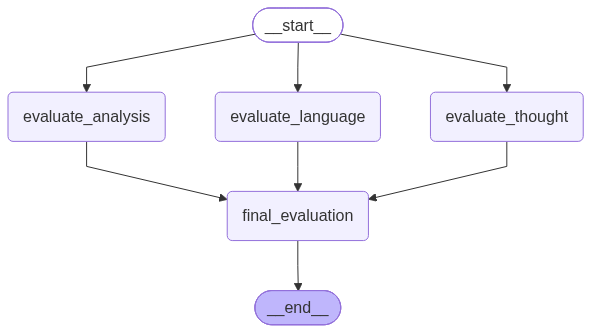

In [14]:
workflow

In [15]:
initial_state={
    'essay': essay
}
result=workflow.invoke(initial_state)

In [16]:
result

{'essay': 'Artificial Intelligence (AI) is rapidly transforming the world, and India is emerging as one of the key players in this technological revolution. AI refers to machines and systems that can perform tasks requiring human intelligence, such as learning, reasoning, problem-solving, and decision-making. In India, AI is playing a significant role in driving economic growth, improving public services, and addressing social challenges.\n\nOne of the most important roles of AI in India is in economic development and industry. AI is being widely adopted in sectors such as information technology, manufacturing, finance, and e-commerce. Startups and large companies use AI for automation, data analysis, fraud detection, customer support chatbots, and personalized services. This has increased productivity, reduced operational costs, and created new job opportunities in data science, machine learning, and AI engineering.\n\nAI is also making a strong impact on healthcare in India. AI-power